In [8]:
from algs.temporal_kernel import *
from algs.temporal_basis import *
import matplotlib.pyplot as plt
from data.datasets import load_experiment, trim_transient
from algs.bilinear_trajectory_encoder import *
from utils.windows import strided_window_view

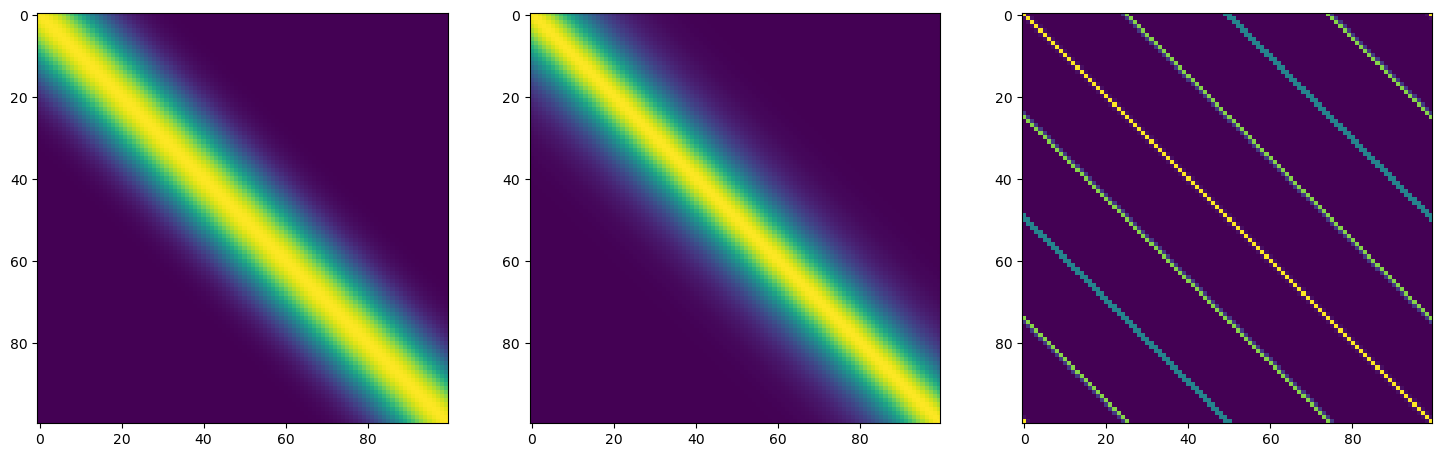

In [2]:
t = np.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 3, figsize=(18, 8))

ax[0].imshow(RBFKernel()(t))
ax[1].imshow(Matern52Kernel()(t))
ax[2].imshow(PeriodicKernel(period=0.25)(t))

In [9]:
x_tr, x_te, y_true, _ = load_experiment('humanoid', trim=True)

In [10]:
x_tr = strided_window_view(x_tr, window=x_te.shape[1], stride=100).reshape(-1, 100, x_tr.shape[-1])

In [11]:
x_tr.shape

(2700, 100, 45)

In [12]:
y_true[:10]

array([False, False,  True, False,  True,  True, False,  True,  True,
       False])

In [13]:
from utils.plotting import plot_channels

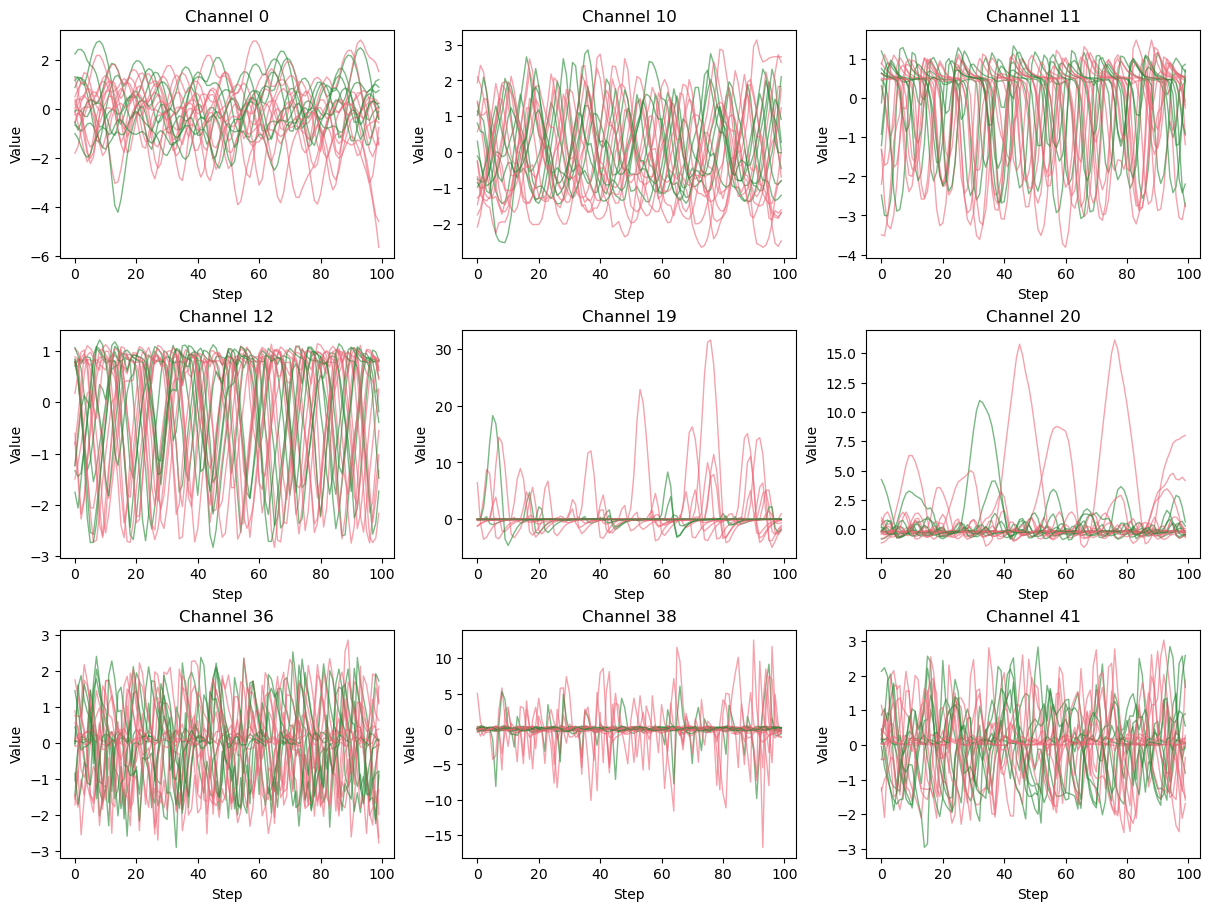

In [18]:
plot_channels(x_te, y_true);

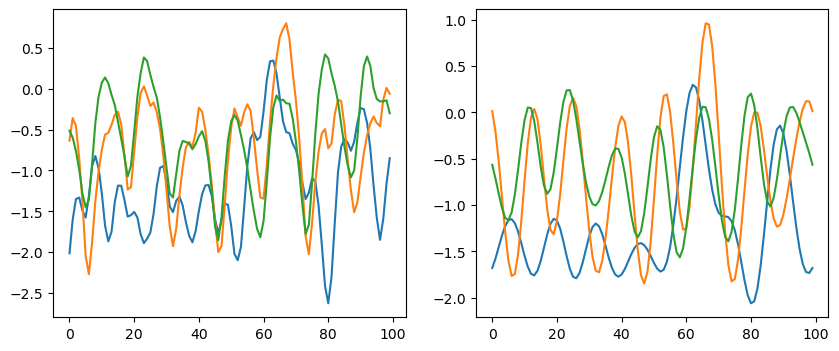

In [ ]:
model = BilinearTrajectoryEncoder(n_spatial_components=0.95,
                                  strategy=OptStrategy.SPACE_THEN_TIME,
                                  temporal=FourierBasis(n_harmonics=10),
                                  #temporal=Matern52Kernel(length_scale=0.05),
                                  )
model.fit(x_tr)
x_tr_rec = model.reconstruct(x_tr)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x_tr[0,:,:3])
ax[1].plot(x_tr_rec[0,:,:3])

In [56]:
model.get_stats(x_tr)

{'relative_error': np.float64(0.583539255526424),
 'compression_ratio': 8.241758241758241,
 'components_kept': 26}

In [57]:
x_tr_rec.shape

(2700, 100, 45)

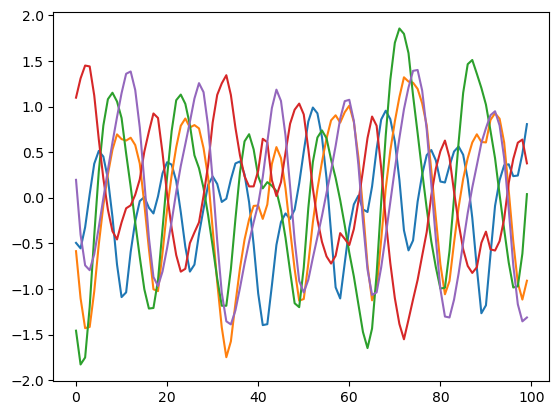

In [59]:
plt.plot(x_te[0,:,:5])